### Implementation of Perceptron using Scikit Learn Python API

In [1]:
# Loading the Iris Dataset 

from sklearn import datasets
import numpy as np 

iris = datasets.load_iris()

X = iris.data[: , [2, 3]]
y = iris.target

print("Class Labels: ", np.unique(y))


Class Labels:  [0 1 2]


In [10]:
# Splitting the data

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y , test_size = 0.3, random_state = 1, stratify = y)

# Verifying proportion 

print(np.bincount(y))
print(np.bincount(y_train))
print(np.bincount(y_test))

[50 50 50]
[35 35 35]
[15 15 15]


In [11]:
# Standardizing the data

from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

sc.fit(X_train) # Fit the Training data to find out mean and std

# Apply the same on both train and test splits

X_train_std = sc.transform(X_train)
X_test_std = sc.transform(X_test)

In [13]:
# Defining the model 

from sklearn.linear_model import Perceptron

ppn = Perceptron(eta0 = 0.1, random_state = 1)


# Fit the training data and training labels
ppn.fit(X_train_std, y_train)

Perceptron(eta0=0.1, random_state=1)

In [17]:
# Evaluate your model

y_pred = ppn.predict(X_test_std)
print("Misclassified Examples:", (y_pred != y_test).sum())

Misclassified Examples: 1


In [21]:
from sklearn.metrics import accuracy_score 

print("Accuracy: %.3f" % accuracy_score(y_test, y_pred))

Accuracy: 0.978


In [22]:
print("Accuracy: %.3f" % ppn.score(X_test_std, y_test))

Accuracy: 0.978


In [23]:
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt

# To check recent matplotlib compatibility
import matplotlib
from distutils.version import LooseVersion


def plot_decision_regions(X, y, classifier, test_idx=None, resolution=0.02):

    # setup marker generator and color map
    markers = ('s', 'x', 'o', '^', 'v')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])

    # plot the decision surface
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))
    Z = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    Z = Z.reshape(xx1.shape)
    plt.contourf(xx1, xx2, Z, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0], 
                    y=X[y == cl, 1],
                    alpha=0.8, 
                    color=colors[idx],
                    marker=markers[idx], 
                    label=cl, 
                    edgecolor='black')

    # highlight test examples
    if test_idx:
        # plot all examples
        X_test, y_test = X[test_idx, :], y[test_idx]

        
        if LooseVersion(matplotlib.__version__) < LooseVersion('0.3.4'):
            plt.scatter(X_test[:, 0],
                        X_test[:, 1],
                        c='',
                        edgecolor='black',
                        alpha=1.0,
                        linewidth=1,
                        marker='o',
                        s=100, 
                        label='test set')
        else:
            plt.scatter(X_test[:, 0],
                        X_test[:, 1],
                        c='none',
                        edgecolor='black',
                        alpha=1.0,
                        linewidth=1,
                        marker='o',
                        s=100, 
                        label='test set')    

C:\Users\sayed mohamed saqib\AppData\Local\Temp\ipykernel_13968\3452639419.py:28: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x=X[y == cl, 0],
C:\Users\sayed mohamed saqib\AppData\Local\Temp\ipykernel_13968\3452639419.py:42: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if LooseVersion(matplotlib.__version__) < LooseVersion('0.3.4'):


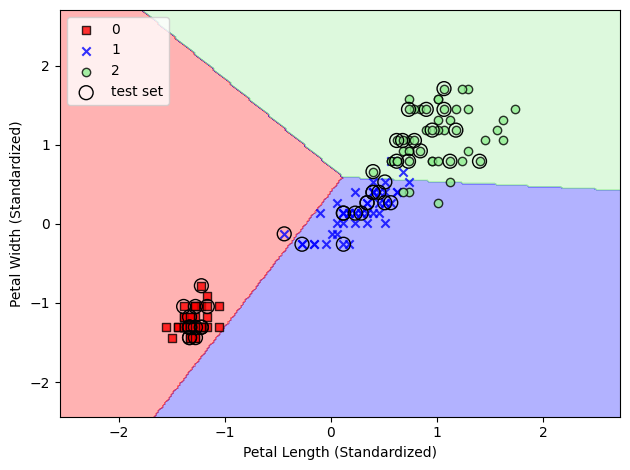

In [26]:
X_combined_std = np.vstack((X_train_std, X_test_std)) 
y_combined = np.hstack((y_train, y_test))

plot_decision_regions(X = X_combined_std, y = y_combined, classifier = ppn, test_idx = range(105, 150))

plt.xlabel("Petal Length (Standardized)")
plt.ylabel("Petal Width (Standardized)")
plt.tight_layout()
plt.legend(loc = 'upper left')
plt.show()